In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [16]:
import matplotlib.pyplot as plt

In [8]:
image_path = []
labels = []

for i in os.listdir("datasets/afhq"):
    for label in os.listdir(f"datasets/afhq/{i}"):
        for image in os.listdir(f"datasets/afhq/{i}/{label}"):
            image_path.append(f"datasets/afhq/{i}/{label}/{image}")
            labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['cat' 'dog' 'wild']


,image_path,labels
0,datasets/afhq/train/cat/flickr_cat_000002.jpg,cat
1,datasets/afhq/train/cat/flickr_cat_000003.jpg,cat
2,datasets/afhq/train/cat/flickr_cat_000004.jpg,cat
3,datasets/afhq/train/cat/flickr_cat_000005.jpg,cat
4,datasets/afhq/train/cat/flickr_cat_000006.jpg,cat


In [11]:
train = data_df.sample(frac=0.7)
test = data_df.drop(train.index)

val = test.sample(frac=0.5)
test = test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

(11291, 2)
(2420, 2)
(2419, 2)


In [12]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [13]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform = None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)
    
    def __len__(self):
        return self.dataframe.shape[0]
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image).to(device)
        return image, label

In [15]:
train_dataset = CustomImageDataset(dataframe= train, transform= transform)
val_dataset = CustomImageDataset(dataframe= val, transform= transform)
test_dataset = CustomImageDataset(dataframe= test, transform= transform)

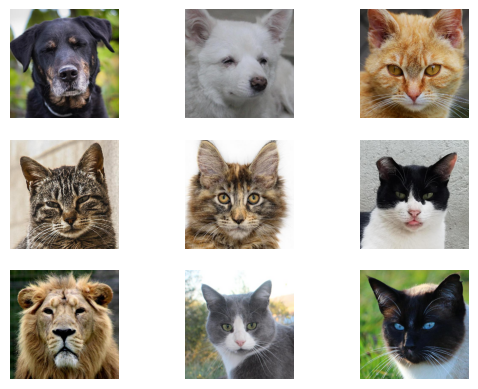

In [24]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
    for col in range(n_cols):
        image = Image.open(data_df.sample(n = 1)["image_path"].iloc[0]).convert("RGB")
        axarr[row, col].imshow(image)
        axarr[row, col].axis('off')
    
plt.show()

In [22]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [23]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)

In [33]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pooling = nn.MaxPool2d(2, 2)

        self.relu =nn.ReLU()

        self.flatten = nn.Flatten()
        self.linear = nn.Linear((128 * 16 * 16), 128)

        self.output = nn.Linear(128, len(data_df['labels'].unique()))

    def forward(self, x):
        x = self.conv1(x)
        x = self.pooling(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.pooling(x)
        x = self.relu(x)

        x = self.conv3(x)
        x = self.pooling(x)
        x = self.relu(x)

        x = self.flatten(x)
        x = self.linear(x)
        x = self.output(x)

        return x


In [34]:
model = Net().to(device)

In [35]:
from torchsummary import summary
summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [37]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_loss_val = 0
    total_acc_val = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()
        train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()

        total_acc_train += train_acc
        optimizer.step()

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)

            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
            total_acc_val += val_acc
    
    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_validation_plot.append(round(total_acc_val/1000, 4))
    total_acc_train_plot.append(round((total_acc_train/train_dataset.__len__()) * 100, 4))
    total_acc_validation_plot.append(round((total_acc_val/val_dataset.__len__()) * 100, 4))

    print(f'''Epoch no. {epoch+1}/{EPOCHS} Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy: {round((total_acc_train/train_dataset.__len__()) * 100, 4)}
              Validation Loss: {round(total_acc_val/1000, 4)} Validation Accuracy: {round((total_acc_val/val_dataset.__len__()) * 100, 4)}''')
    print("="*75)

Epoch no. 1/10 Train Loss: 0.3398 Train Accuracy: 79.7981
              Validation Loss: 2.231 Validation Accuracy: 92.1901
Epoch no. 2/10 Train Loss: 0.1397 Train Accuracy: 92.8173
              Validation Loss: 2.291 Validation Accuracy: 94.6694
Epoch no. 3/10 Train Loss: 0.087 Train Accuracy: 95.8108
              Validation Loss: 2.298 Validation Accuracy: 94.9587
Epoch no. 4/10 Train Loss: 0.0633 Train Accuracy: 96.8825
              Validation Loss: 2.318 Validation Accuracy: 95.7851
Epoch no. 5/10 Train Loss: 0.046 Train Accuracy: 97.5821
              Validation Loss: 2.311 Validation Accuracy: 95.4959
Epoch no. 6/10 Train Loss: 0.033 Train Accuracy: 98.335
              Validation Loss: 2.329 Validation Accuracy: 96.2397
Epoch no. 7/10 Train Loss: 0.0235 Train Accuracy: 98.8221
              Validation Loss: 2.319 Validation Accuracy: 95.8264
Epoch no. 8/10 Train Loss: 0.0171 Train Accuracy: 99.1675
              Validation Loss: 2.337 Validation Accuracy: 96.5702
Epoch no. 9/